In [1]:
import csv

with open("processed-actual-outages.csv") as file:
    csv_reader = csv.DictReader(file)
    actual_data = list(csv_reader)

In [2]:
from datetime import datetime

from tqdm import tqdm

date_keys = ["OutDatetime", "MinTimeStamp", "MaxTimeStamp"]

for row in tqdm(actual_data):
    row["PTID"] = int(row["PTID"])
    row["Voltage"] = int(row["Voltage"])
    for key in date_keys:
        row[key] = datetime.strptime(row[key], "%Y-%m-%d %H:%M:%S")

actual_data[0]

  0%|          | 0/74063 [00:00<?, ?it/s]

100%|██████████| 74063/74063 [00:01<00:00, 60295.78it/s]


{'PTID': 26053,
 'Name': 'MOUNTAIN-SWANROAD_115_104-3',
 'OutDatetime': datetime.datetime(2005, 1, 1, 0, 0),
 'MinTimeStamp': datetime.datetime(2012, 9, 11, 11, 52, 17),
 'MaxTimeStamp': datetime.datetime(2013, 8, 8, 8, 37, 17),
 'Voltage': 115,
 'FirstBus': 'MOUNTAIN',
 'SecondBus': 'SWANROAD',
 'OutageType': 'Planned'}

In [3]:
from pathlib import Path

output_path = Path("output")
output_path.mkdir(exist_ok=True)

# Dropped periods

In [4]:
from datetime import timedelta

# set current time as the day for the first row
current_date = datetime(2005, 1, 1)
end_date = datetime(2026, 3, 1)
day_timedelta = timedelta(days=1)
no_event_dates = []
while current_date < end_date:
    records = [
        row
        for row in actual_data
        if current_date <= row["OutDatetime"] < current_date + day_timedelta
    ]
    if len(records) == 0:
        no_event_dates.append(current_date.strftime("%Y-%m-%d"))
    current_date += day_timedelta

(output_path / "no_event_dates.txt").write_text("\n".join(no_event_dates))

8711

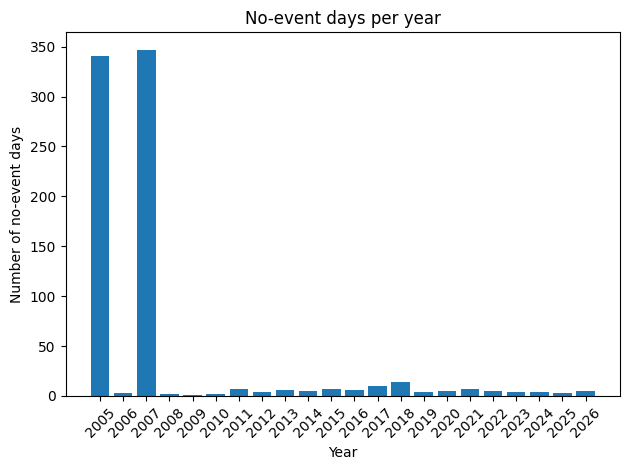

In [5]:
from collections import Counter

import matplotlib.pyplot as plt

# count no-event days per year (no_event_dates is defined in the notebook)
years = [int(d.split("-")[0]) for d in no_event_dates]
counts = Counter(years)
years, counts = list(zip(*sorted(counts.items(), key=lambda x: x[0])))


fig, ax = plt.subplots()
ax.bar([str(y) for y in years], counts)
ax.set_xlabel("Year")
ax.set_ylabel("Number of no-event days")
ax.set_title("No-event days per year")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "no_event_days_per_year.pdf", dpi=300)

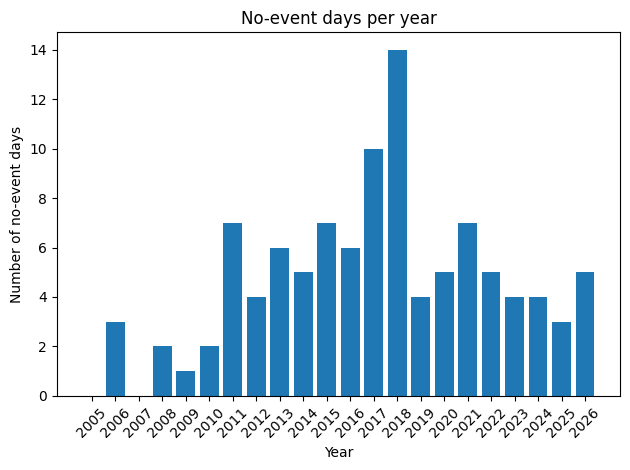

In [6]:
counts = list(counts)
counts[0] = 0
counts[2] = 0

fig, ax = plt.subplots()
ax.bar([str(y) for y in years], counts)
ax.set_xlabel("Year")
ax.set_ylabel("Number of no-event days")
ax.set_title("No-event days per year")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "no_event_days_per_year-nooutlier.pdf", dpi=300)

## drop and rise in 2017-2018 and 2018-2019

In [7]:
START_YEAR = 2008
END_YEAR = 2025
years = list(range(START_YEAR, END_YEAR + 1))


def count_devices(till_year):
    return len(
        set(row["PTID"] for row in actual_data if row["OutDatetime"].year <= till_year)
    )


devices_per_year = [
    count_devices(year) - count_devices(year - 1)
    for year in range(START_YEAR, END_YEAR + 1)
]

In [8]:
len(years), len(devices_per_year)

(18, 18)

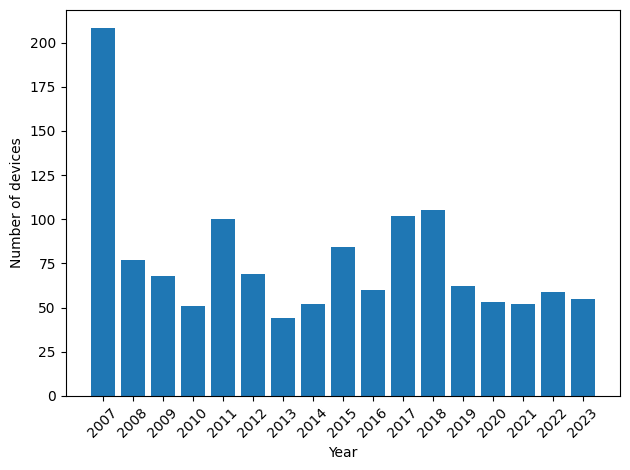

In [9]:
fig, ax = plt.subplots()
ax.bar([str(y - 1) for y in years[:-1]], devices_per_year[:-1])
ax.set_xlabel("Year")
ax.set_ylabel("Number of devices")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "new_devices.pdf", dpi=300)

# Basic countings

In [10]:
import igraph

our_bus_set = set(
    [row[key] for row in actual_data for key in ["FirstBus", "SecondBus"]]
)

print(f"num vertices: {len(our_bus_set)}")

bus_name_to_index = {
    bus_name: i for i, bus_name in enumerate(sorted(list(our_bus_set)))
}
index_to_bus_name = {
    i: bus_name for i, bus_name in enumerate(sorted(list(our_bus_set)))
}
n = len(bus_name_to_index)
g = igraph.Graph(n=len(bus_name_to_index), directed=False)

edge_set = set()
for datum in actual_data:
    b1, b2 = datum["FirstBus"], datum["SecondBus"]
    b1_index, b2_index = bus_name_to_index[b1], bus_name_to_index[b2]
    edge_set.add((b1_index, b2_index))
g.add_edges(list(edge_set))

print(g.is_connected())

num vertices: 1376
True


In [11]:
ref_time = datetime(2008, 1, 1)
len(actual_data), len([row for row in actual_data if ref_time <= row["OutDatetime"]])

(74063, 70079)

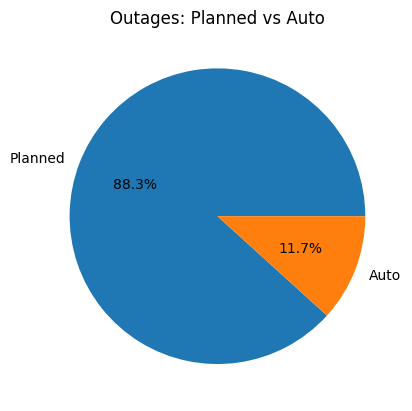

In [12]:
n = len(actual_data)
n_planned = len([row for row in actual_data if row["OutageType"] == "Planned"])
n_auto = len([row for row in actual_data if row["OutageType"] == "Auto"])

fig, ax = plt.subplots()
ax.pie([n_planned, n_auto], labels=["Planned", "Auto"], autopct="%1.1f%%")
ax.set_title("Outages: Planned vs Auto")

plt.savefig(output_path / "planned_vs_auto.pdf", dpi=300)

defaultdict(<class 'int'>, {'lower': 37, '69': 3322, '115/120': 32750, '132/138': 17333, '220/230': 7287, '345': 11663, '500': 1427, '735/765': 244})


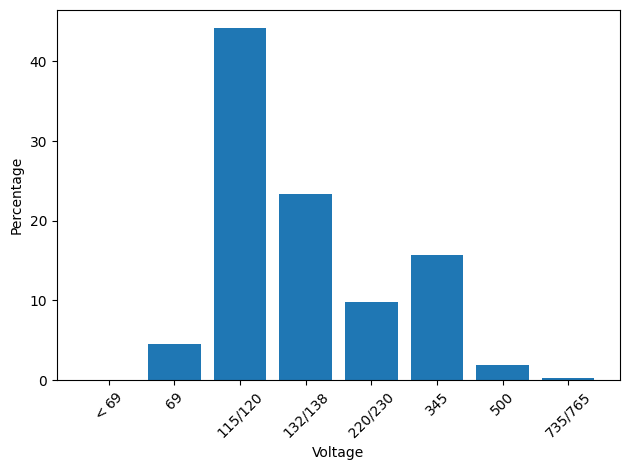

In [13]:
from collections import defaultdict

group_map = {
    27: "lower",
    34: "lower",
    69: "69",
    115: "115/120",
    120: "115/120",
    132: "132/138",
    138: "132/138",
    220: "220/230",
    230: "220/230",
    345: "345",
    500: "500",
    735: "735/765",
    765: "735/765",
}
counts = Counter([row["Voltage"] for row in actual_data])
voltages, counts = list(zip(*sorted(counts.items(), key=lambda x: x[0])))
grouped = defaultdict(int)
for v, c in zip(voltages, counts):
    grouped[group_map[v]] += c
print(grouped)

x = [r"$<69$", "69", "115/120", "132/138", "220/230", "345", "500", "735/765"]
y = [grouped[label] for label in x]
total = sum(y)
percentage = [count / total * 100 for count in y]


fig, ax = plt.subplots()
ax.bar(x, percentage)
ax.set_xlabel("Voltage")
ax.set_ylabel("Percentage")
# ax.set_title("Line voltages")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "voltages.pdf", dpi=300)

### Line outage frequency histogram

In [14]:
import numpy as np

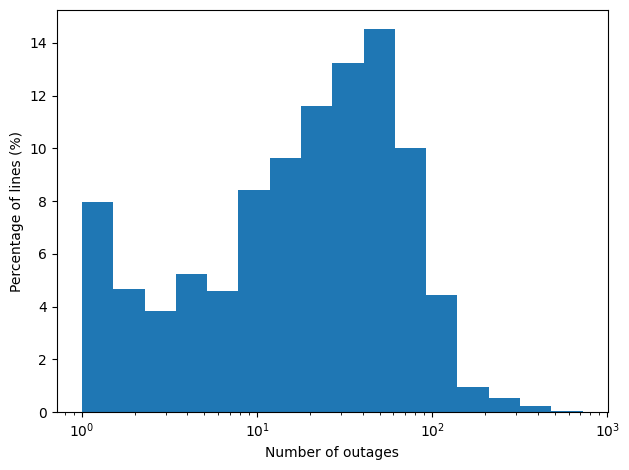

In [15]:
counts = Counter([row["PTID"] for row in actual_data])
freqs = list(counts.values())

fig, ax = plt.subplots()
bins = np.logspace(np.log10(min(freqs)), np.log10(max(freqs)), 17)
ax.hist(freqs, bins=bins, weights=np.ones(len(freqs)) / len(freqs) * 100)

ax.set_xscale("log")
ax.set_xlabel("Number of outages")
ax.set_ylabel("Percentage of lines (%)")
# ax.set_title("Line outage frequency histogram")
plt.tight_layout()
plt.savefig(output_path / "line_outage_frequency_histogram.pdf", dpi=300)

In [16]:
bins

array([  1.        ,   1.50876275,   2.27636504,   3.43449479,
         5.18183782,   7.81816389,  11.79575448,  17.796995  ,
        26.85144316,  40.51245731,  61.12368662,  92.2211417 ,
       139.13982364, 209.92898336, 316.73303087, 477.87499961,
       721.        ])

# Form failure scenarios

In [17]:
actual_data = [row for row in actual_data if row["OutDatetime"].year >= 2008]

actual_data_auto = [row for row in actual_data if row["OutageType"] == "Auto"]
actual_data_planned = [row for row in actual_data if row["OutageType"] == "Planned"]

In [18]:
# Form cascading failures based on time thresholds
# TIME THRESHOLDS (in seconds)
SAME_GENERATION_THRESHOLD = 60 * 1
SAME_CASCADING_THRESHOLD = 3600

cascading_failures = []
current_cascade = [[actual_data[0]]]
for datum in actual_data[1:]:
    last_out_datetime = current_cascade[-1][-1]["OutDatetime"]
    current_out_datetime = datum["OutDatetime"]
    time_diff = (current_out_datetime - last_out_datetime).total_seconds()
    if time_diff <= SAME_GENERATION_THRESHOLD:
        current_cascade[-1].append(datum)
        continue
    if time_diff <= SAME_CASCADING_THRESHOLD:
        current_cascade.append([datum])
        continue
    if time_diff > SAME_CASCADING_THRESHOLD:
        cascading_failures.append(current_cascade)
        current_cascade = [[datum]]
        continue
len(cascading_failures)

29862

In [19]:
generation_sizes = [len(cascading_failure) for cascading_failure in cascading_failures]
cascading_failure_sizes = [
    sum(len(gen) for gen in cascading_failure)
    for cascading_failure in cascading_failures
]
initial_failure_sizes = [
    len(cascading_failure[0]) for cascading_failure in cascading_failures
]

In [20]:
len(cascading_failures)

29862

In [21]:
from typing import Optional

import numpy as np
import powerlaw


def plot_log_log(
    size_list: list[int],
    xmin: Optional[int] = None,
    xmax: Optional[int] = None,
    dpi: Optional[int] = 300,
    x_label: Optional[str] = "",
    y_label: Optional[str] = "",
):
    """Plot CCDF and fit a powerlaw distribution line to the points

    :param size_list: list of initial failure size, cascading failure size, cascading generations, etc.
    """
    fig, ax = plt.subplots(dpi=dpi)

    # plot log-log CCDF
    n = len(size_list)
    values, counts = np.unique(size_list, return_counts=True)
    order = np.argsort(values)
    values = values[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / n
    ax.loglog(values, ccdf, marker="o", linestyle="none")
    # ax.set_xlim(1, 50)

    # fit a line
    fit = powerlaw.Fit(
        size_list,
        discrete=True,
        verbose=False,
        survival=True,
        xmin=xmin,
        xmax=xmax,
    )
    print("alpha:", fit.power_law.alpha)
    print("xmin :", fit.power_law.xmin)
    fit.power_law.plot_pdf(ax=ax, linestyle="--", label="Power-law fit")

    # set labels
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    return ax

alpha: 2.826865927180013
xmin : 3.0


<Axes: >

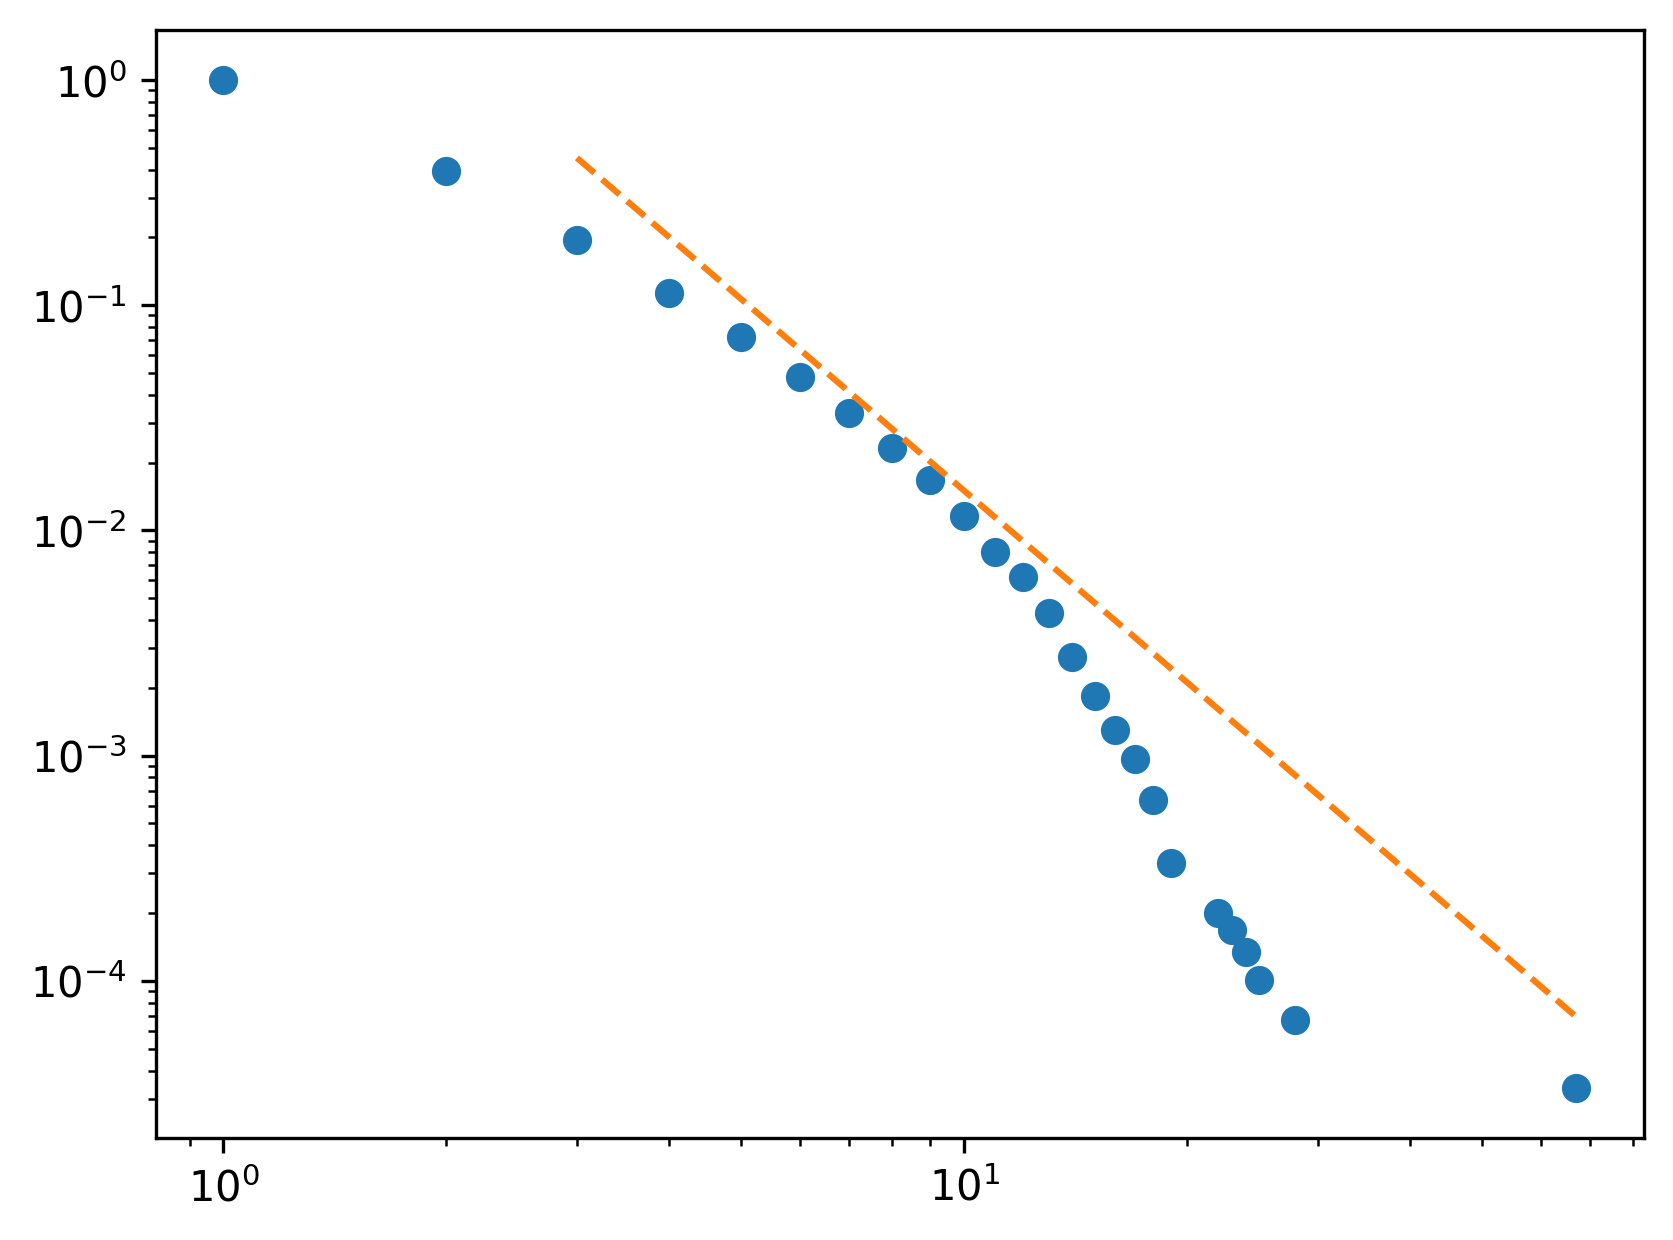

In [22]:
plot_log_log(generation_sizes)

alpha: 3.3955754481798444
xmin : 6.0


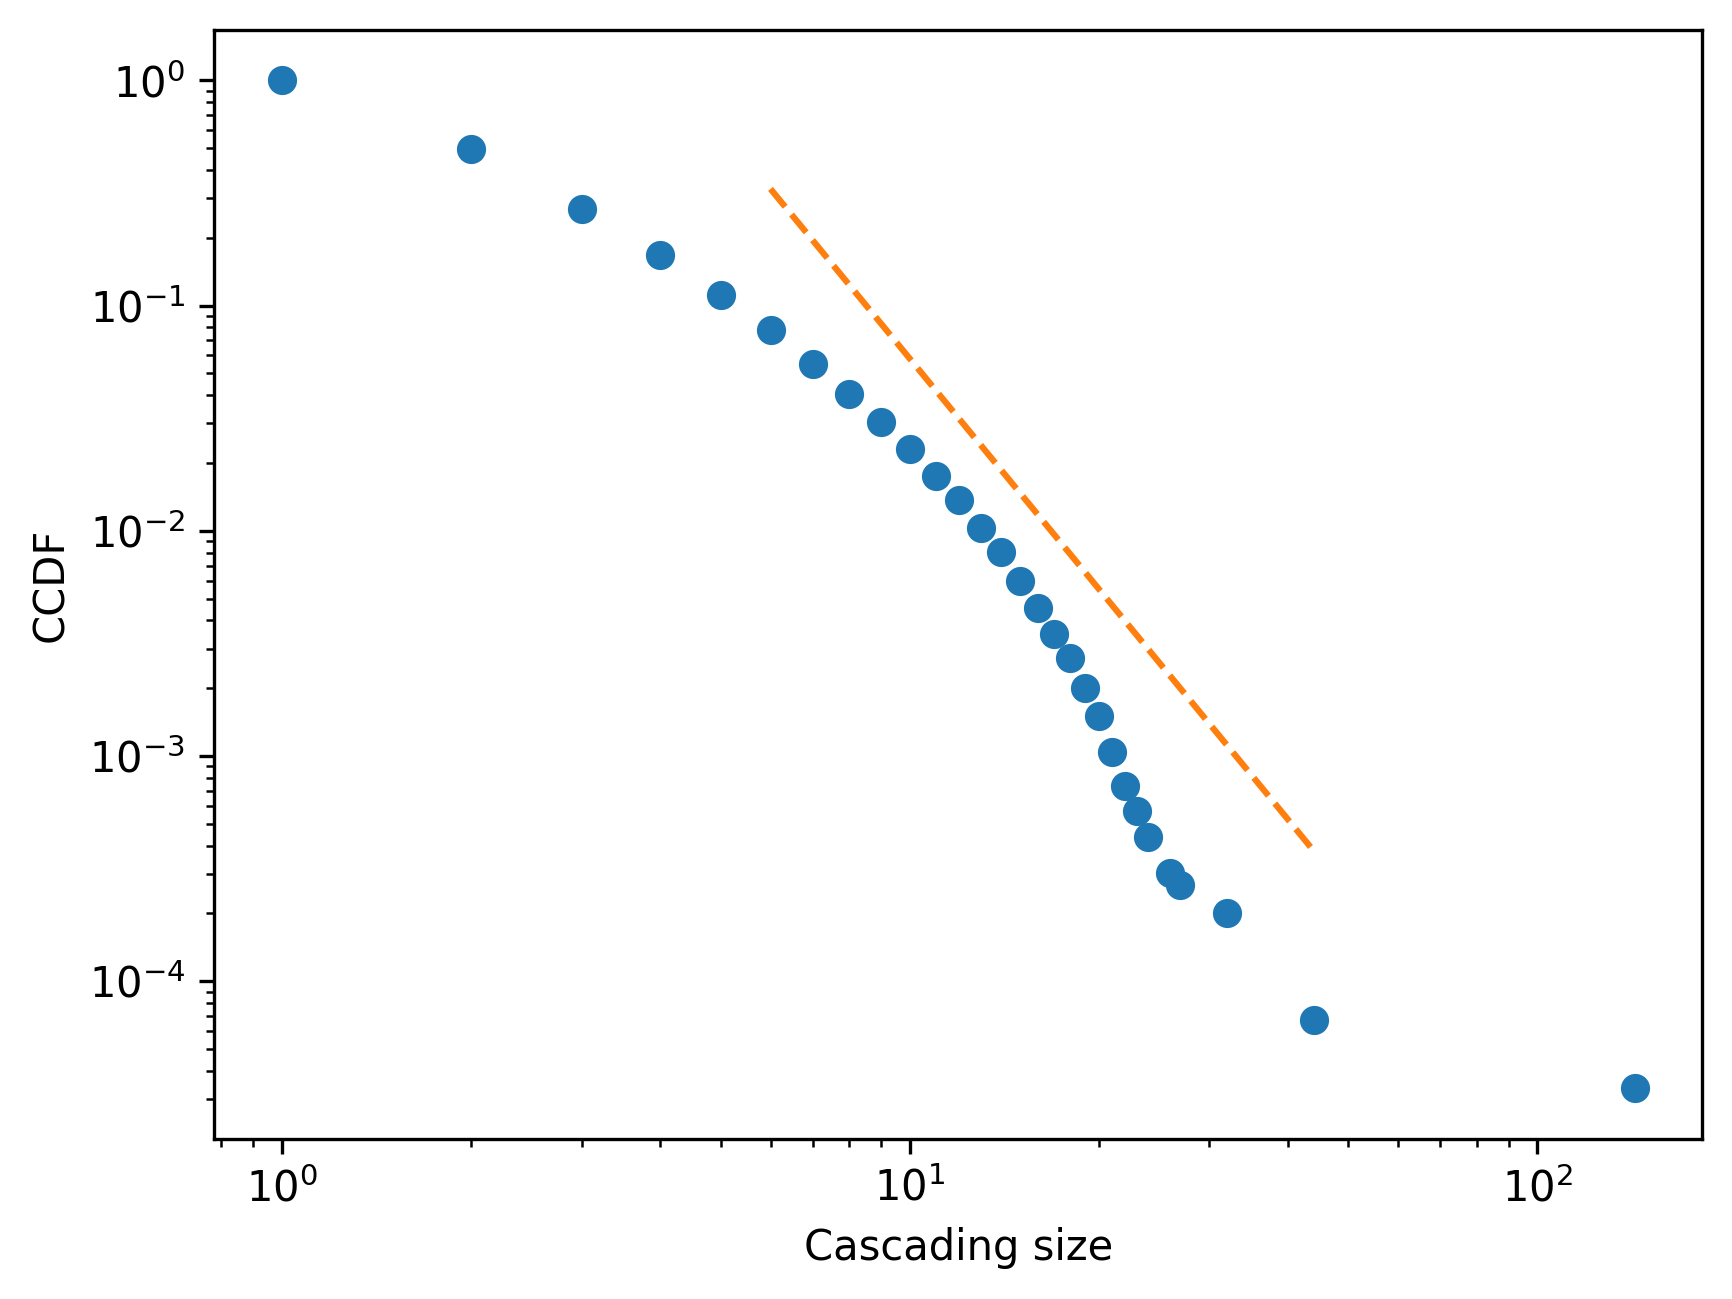

In [23]:
plot_log_log(
    cascading_failure_sizes, xmin=6, xmax=50, x_label="Cascading size", y_label="CCDF"
)
plt.savefig(output_path / "cascading_failure_sizes.pdf", dpi=300)

# Rebound

In [24]:
cascading_failures[0]

[[{'PTID': 25795,
   'Name': 'LAMBTON_-ST.CLAIR_345_L4D',
   'OutDatetime': datetime.datetime(2008, 1, 1, 3, 13),
   'MinTimeStamp': datetime.datetime(2008, 1, 1, 3, 22, 18),
   'MaxTimeStamp': datetime.datetime(2008, 1, 1, 23, 57, 18),
   'Voltage': 345,
   'FirstBus': 'LAMBTON_',
   'SecondBus': 'ST.CLAIR',
   'OutageType': 'Auto'}]]

In [25]:
for scenario in cascading_failures:
    if len(scenario) > 21 and scenario[0][0]["OutDatetime"].year > 2007:
        break
print(len(scenario), scenario)

28 [[{'PTID': 101015041, 'Name': 'BARBOURH-MEEK.JCT_345_395-1', 'OutDatetime': datetime.datetime(2011, 3, 28, 6, 30), 'MinTimeStamp': datetime.datetime(2011, 3, 28, 10, 57, 19), 'MaxTimeStamp': datetime.datetime(2011, 3, 28, 23, 57, 21), 'Voltage': 345, 'FirstBus': 'BARBOURH', 'SecondBus': 'MEEK.JCT', 'OutageType': 'Auto'}], [{'PTID': 25900, 'Name': 'MNCHESTR-MEEK.JCT_345_395-3', 'OutDatetime': datetime.datetime(2011, 3, 28, 6, 32), 'MinTimeStamp': datetime.datetime(2011, 3, 28, 6, 37, 18), 'MaxTimeStamp': datetime.datetime(2011, 3, 28, 23, 57, 21), 'Voltage': 345, 'FirstBus': 'MNCHESTR', 'SecondBus': 'MEEK.JCT', 'OutageType': 'Planned'}], [{'PTID': 325648, 'Name': 'REYNOLDS-RVSD_TAP_115_4', 'OutDatetime': datetime.datetime(2011, 3, 28, 6, 44), 'MinTimeStamp': datetime.datetime(2011, 3, 28, 6, 47, 18), 'MaxTimeStamp': datetime.datetime(2011, 3, 31, 23, 57, 22), 'Voltage': 115, 'FirstBus': 'REYNOLDS', 'SecondBus': 'RVSD_TAP', 'OutageType': 'Planned'}], [{'PTID': 25377, 'Name': 'CHATGUAY

In [26]:
def is_active(row, dt):
    if row["OutDatetime"] <= dt <= row["MaxTimeStamp"]:
        return False
    return True


time_resolution = timedelta(minutes=1)
current_time = min([row["OutDatetime"] for gen in scenario for row in gen])
current_time -= timedelta(days=1)
max_time = max([row["MaxTimeStamp"] for gen in scenario for row in gen])
max_time += timedelta(days=3)

flat_scenario = sum(scenario, [])
total_voltage = sum([row["Voltage"] for row in flat_scenario])
time_ref = current_time.timestamp()
t_list, v_list = [], []
while current_time < max_time:
    current_time += time_resolution
    t_list.append(current_time.timestamp() - time_ref)
    active_v = sum(
        [row["Voltage"] for row in flat_scenario if is_active(row, current_time)]
    )
    v_list.append(active_v / total_voltage)

In [27]:
flat_scenario[0]["OutDatetime"], flat_scenario[0]["MaxTimeStamp"]

(datetime.datetime(2011, 3, 28, 6, 30),
 datetime.datetime(2011, 3, 28, 23, 57, 21))

In [ ]:
def plot_log_log(
    size_list: list[int],
    xmin: Optional[int] = None,
    xmax: Optional[int] = None,
    dpi: Optional[int] = 100,
    x_label: Optional[str] = "",
    y_label: Optional[str] = "",
):
    """Plot CCDF and fit a powerlaw distribution line to the points

    :param size_list: list of initial failure size, cascading failure size, cascading generations, etc.
    """
    fig, ax = plt.subplots(dpi=dpi)

    # plot log-log CCDF
    n = len(size_list)
    values, counts = np.unique(size_list, return_counts=True)
    order = np.argsort(values)
    values = values[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / n
    ax.loglog(values, ccdf, marker="o", linestyle="none")
    # ax.set_xlim(1, 50)

    # fit a line
    fit = powerlaw.Fit(
        size_list,
        discrete=True,
        verbose=False,
        survival=True,
        xmin=xmin,
        xmax=xmax,
    )
    print("alpha:", fit.power_law.alpha)
    print("xmin :", fit.power_law.xmin)
    fit.power_law.plot_pdf(ax=ax, linestyle="--", label="Power-law fit")

    # set labels
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    return ax

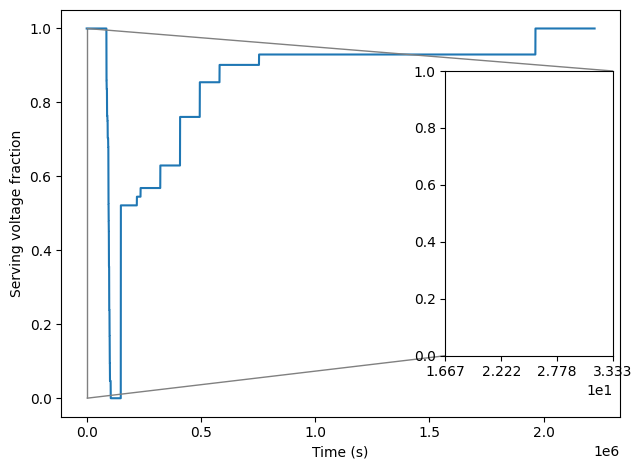

In [32]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots()
ax.plot(t_list, v_list)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Serving voltage fraction")
# ax.set_title("Rebound scenario voltage over time")
plt.tight_layout()

# define the zoom window on the x‑axis
x_start = (6 * 10**4) / 3600
x_end = x_start + (6 * 10**4) / 3600

# add inset axes and plot same data there
axins = inset_axes(ax, width="30%", height="70%", loc="center right")
axins.plot(t_list, v_list)
axins.set_xlim(x_start, x_end)
axins.set_ylim(min(v_list), max(v_list))

ticks = np.linspace(x_start, x_end, 4)
axins.set_xticks(ticks)
axins.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# draw a box on the main axes to show the zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="0.5")

plt.savefig(output_path / "rebound_voltage_time_inset.pdf", dpi=300)

In [33]:
# plot couple of scenarios
plots_t_lists, plots_v_lists = [], []
for scenario in cascading_failures:
    if not (len(scenario) > 21 and scenario[0][0]["OutDatetime"].year > 2007):
        continue
    current_time = min([row["OutDatetime"] for gen in scenario for row in gen])
    current_time -= timedelta(days=1)
    max_time = max([row["MaxTimeStamp"] for gen in scenario for row in gen])
    max_time += timedelta(days=3)

    flat_scenario = sum(scenario, [])
    total_voltage = sum([row["Voltage"] for row in flat_scenario])
    time_ref = current_time.timestamp()
    t_list, v_list = [], []
    while current_time < max_time:
        current_time += time_resolution
        t_list.append(current_time.timestamp() - time_ref)
        active_v = sum(
            [row["Voltage"] for row in flat_scenario if is_active(row, current_time)]
        )
        v_list.append(active_v / total_voltage)
    plots_t_lists.append(t_list)
    plots_v_lists.append(v_list)

298655


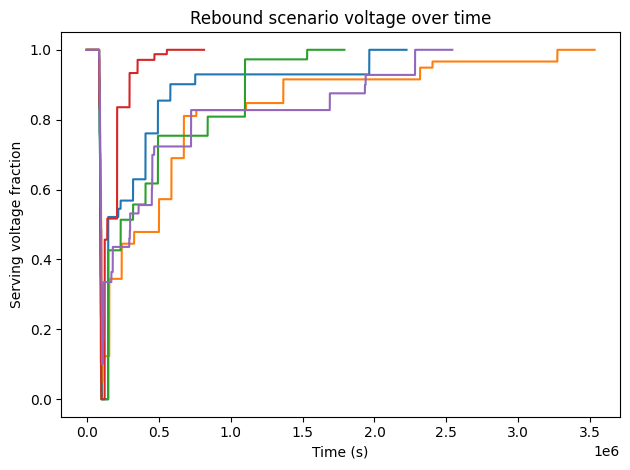

In [34]:
fig, ax = plt.subplots()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Serving voltage fraction")
ax.set_title("Rebound scenario voltage over time")
for t_list, v_list in zip(plots_t_lists, plots_v_lists):
    if len(t_list) > 10**5:
        print(len(t_list))
        continue
    ax.plot(t_list, v_list)
plt.tight_layout()
plt.savefig(output_path / "rebound_voltage_time_multiple.pdf", dpi=300)

# Hypotheses

Time between an auto event to its previous scheduled event is a sign of memory in the power networks if it follows a power law distribution.

In [35]:
time_list = []
for old_outage, current_outage in zip(actual_data, actual_data[1:]):
    if old_outage["OutageType"] == "Planned" and current_outage["OutageType"] == "Auto":
        delta = current_outage["OutDatetime"] - old_outage["OutDatetime"]
        time_list.append(delta.total_seconds())

alpha: 2.7369790950236967
xmin : 19320.0


<Axes: >

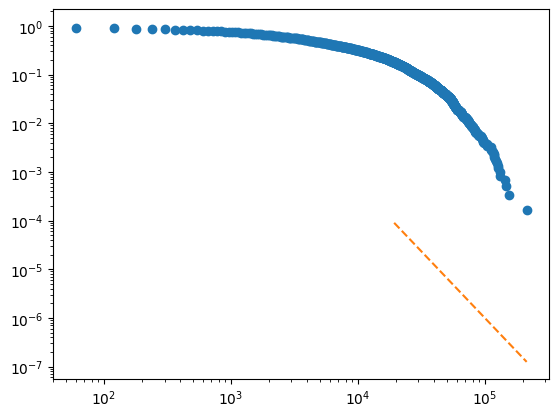

In [36]:
plot_log_log(time_list)

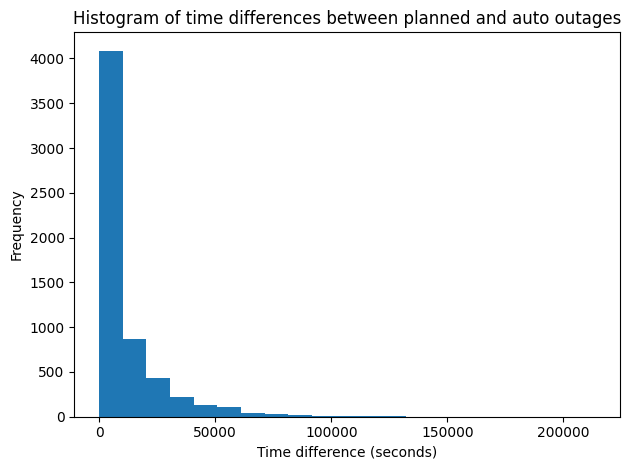

In [37]:
fig, ax = plt.subplots()
ax.hist([min(t, 3600 * 72) for t in time_list], bins=21)
ax.set_xlabel("Time difference (seconds)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of time differences between planned and auto outages")
plt.tight_layout()
plt.savefig(output_path / "time_list_histogram.pdf", dpi=300)

check recovery time for elements

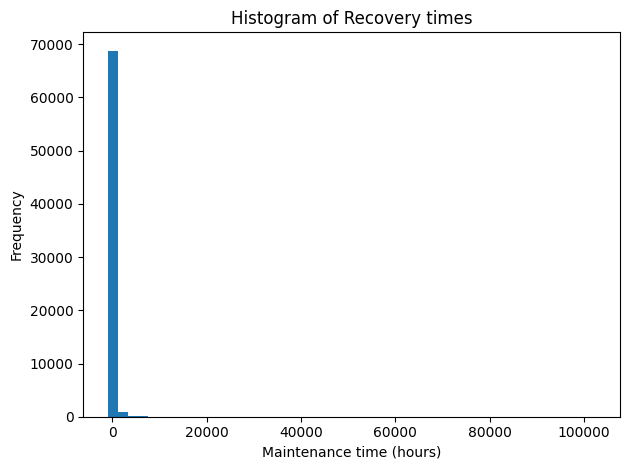

In [38]:
recovery_time = [
    (row["MaxTimeStamp"] - row["OutDatetime"]).total_seconds() for row in actual_data
]

fig, ax = plt.subplots()
ax.hist([t / 3600 for t in recovery_time], bins=48)
ax.set_xlabel("Maintenance time (hours)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of Recovery times")
plt.tight_layout()
plt.savefig(output_path / "maintenance_time_histogram.pdf", dpi=300)

In [39]:
recovery_time_days = [t / 3600 / 24 for t in recovery_time]

alpha: 2.1898264318444847
xmin : 30.0


<Axes: >

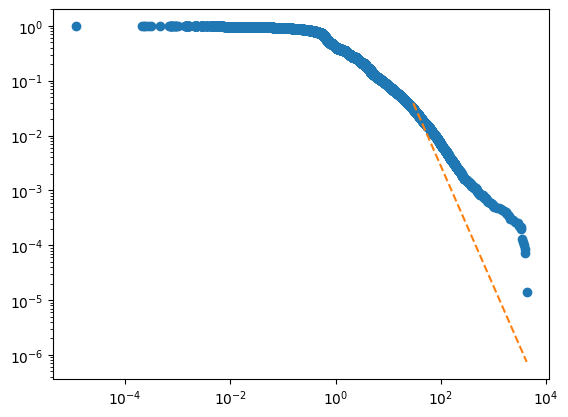

In [50]:
plot_log_log(recovery_time_days, xmin=30)
# , xmax=4 * 10**3

In [41]:
def plot_log_log_manual(
    size_list: list[int],
    xmin: Optional[float] = None,
    xmax: Optional[float] = None,
    ymin: Optional[float] = None,
    ymax: Optional[float] = None,
    dpi: Optional[int] = 300,
    x_label: Optional[str] = "",
    y_label: Optional[str] = "",
):
    """Plot CCDF and fit a powerlaw distribution line to the points

    :param size_list: list of initial failure size, cascading failure size, cascading generations, etc.
    """
    fig, ax = plt.subplots(dpi=dpi)

    # plot log-log CCDF
    n = len(size_list)
    values, counts = np.unique(size_list, return_counts=True)
    order = np.argsort(values)
    values = values[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / n
    ax.loglog(values, ccdf, marker="o", linestyle="none")
    # ax.set_xlim(1, 50)

    # fit a line
    print("alpha:", np.log((ymin - ymax) / (xmax - xmin)))
    ax.loglog([xmin, xmax], [ymin, ymax], linestyle="--")

    # set labels
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    return ax

alpha: -8.509702425698588


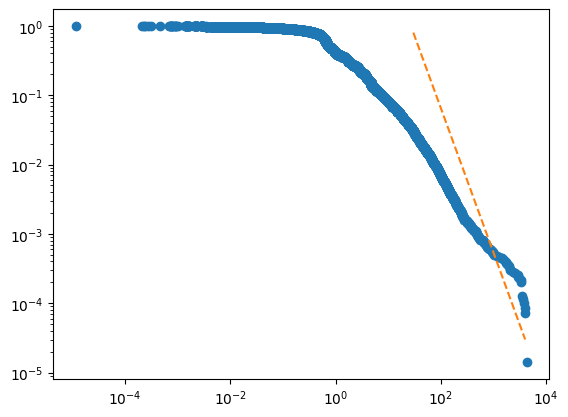

In [55]:
ax = plot_log_log_manual(
    recovery_time_days,
    xmin=30,
    xmax=4 * 10**3,
    ymin=0.8,
    ymax=3 * 10**-5,
    dpi=100,
)

plt.savefig(output_path / "rebound_time_ccdf.pdf", dpi=300)

check effect of season on failures

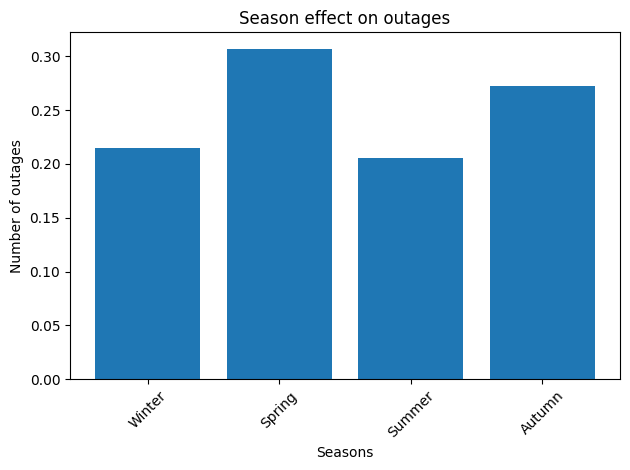

In [36]:
def get_season(dt: datetime) -> str:
    m = dt.month
    if m in (12, 1, 2):
        return "Winter"
    if m in (3, 4, 5):
        return "Spring"
    if m in (6, 7, 8):
        return "Summer"
    return "Autumn"


season = [get_season(row["OutDatetime"]) for row in actual_data]
total = len(season)
season_counter = Counter(season)
seasons = ["Winter", "Spring", "Summer", "Autumn"]
season_counter = [season_counter[season] / total for season in seasons]

fig, ax = plt.subplots()
ax.bar(seasons, season_counter)
ax.set_xlabel("Seasons")
ax.set_ylabel("Number of outages")
ax.set_title("Season effect on outages")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "season.pdf", dpi=300)

check effect of week day on failures

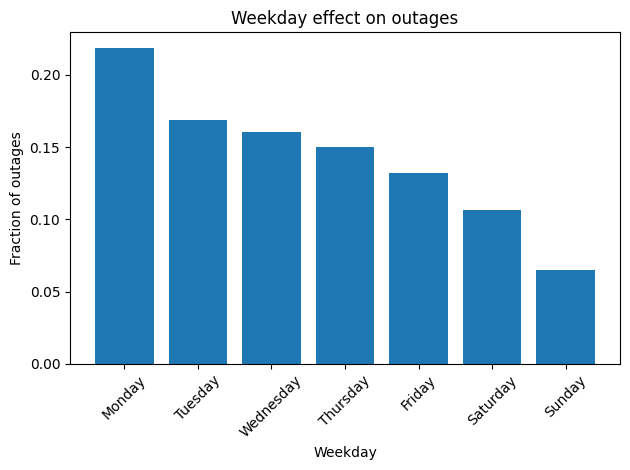

In [37]:
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt


def get_weekday(dt: datetime) -> str:
    # Monday=0 ... Sunday=6
    return dt.strftime("%A")  # e.g., "Monday"


weekdays = [get_weekday(row["OutDatetime"]) for row in actual_data]
total = len(weekdays)

weekday_counter = Counter(weekdays)
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
weekday_freq = [weekday_counter[d] / total for d in weekday_order]

fig, ax = plt.subplots()
ax.bar(weekday_order, weekday_freq)
ax.set_xlabel("Weekday")
ax.set_ylabel("Fraction of outages")
ax.set_title("Weekday effect on outages")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "weekday.pdf", dpi=300)

Check ongoing planned outages on auto outage

In [38]:
keys = ["OutDatetime"]
event_dt_list = sorted([row[key] for row in actual_data for key in keys])

In [39]:
current_outage_pool = []
time = actual_data[0]["OutDatetime"]

ratio_list = []
for dt in tqdm(event_dt_list):
    # filter ongoing outages
    current_outage_pool = [
        row for row in actual_data if row["OutDatetime"] <= dt < row["MaxTimeStamp"]
    ]
    current_outage_pool = sorted(current_outage_pool, key=lambda x: x["OutDatetime"])
    # continue if outage pool is empty or only has an event
    if len(current_outage_pool) < 2:
        continue
    last_event_is_auto = current_outage_pool[-1]["OutageType"] == "Auto"
    others_are_planned = all(
        [row["OutageType"] == "Planned" for row in current_outage_pool[:-1]]
    )
    if last_event_is_auto and others_are_planned:
        t0 = current_outage_pool[0]["OutDatetime"]
        t1 = current_outage_pool[-2]["OutDatetime"]
        t2 = current_outage_pool[-1]["OutDatetime"]
        num = (t2 - t1).total_seconds()
        denum = (t2 - t0).total_seconds()
        ratio_list.append(num / denum)

100%|██████████| 70079/70079 [05:25<00:00, 215.23it/s]
